# Data Collection
1.Gathered raw and inconsistent data from Instagram pages. 
2.Information included: usernames, posts, followers, following, page type, bios, and links
3.Some fields were missing or incomplete, making the dataset noisy.

In [2]:
with open("initialdata.txt","r",encoding="utf-8") as f:
    data=f.read()

In [3]:
data

"intaglobal\n1,946 posts\n6,851 followers\n262 following\nINTA\nNonprofit organization\nThe association of ™ professionals.\ninta.campsite.bio\n\n_anujsinghal\n1,785 posts\n681K followers\n248 following\nAnuj Singhal\nDigital creator\nManaging Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India\nLet’s talk about finance and life\nContact: Singhalanuj1010@gmail.com\nhindi.cnbctv18.com/market-gurukul\n\ncode_flare\n165 posts\n216 followers\n10 following\nThe Journey Notebook | Travel | Food Blogger\nBlogger\n📍 Exploring places & phases of life 🌍\n.\n🍵 From chai breaks to flight takes ✈️\n.\n💫 Travel | Food | Daily life 🌸\nyoutube.com/@thejourneynotebook?si=Z1lPUAl-cPgHAP_a\n\nbangalore_tech_bro\n402 posts\n12.5K followers\n890 following\nRahul | HSR Hustler\nEntrepreneur\n🚀 Building the next Unicorn in Fintech\n☕ 3rd Wave Coffee addict\n💻 Python | React | AI\n📍 HSR Layout, BLR\nlinktr.ee/rahulbuilds\n\nsilkboard_survivor\n55 posts\n1,200 followers\n50 following\nPriya D.\nP

# Data Preprocessing

1.Used Python to read the raw text file (initialdata.txt).
2.kipped empty lines and spaces to avoid parsing errors.
3.Used import re for flexible splitting and cleaning of text.
4.Added defaults like "User Not Mentioned" for missing values.

In [4]:
import re
parse=re.split(r'\n\s*\n',data)
parse

['intaglobal\n1,946 posts\n6,851 followers\n262 following\nINTA\nNonprofit organization\nThe association of ™ professionals.\ninta.campsite.bio',
 '_anujsinghal\n1,785 posts\n681K followers\n248 following\nAnuj Singhal\nDigital creator\nManaging Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India\nLet’s talk about finance and life\nContact: Singhalanuj1010@gmail.com\nhindi.cnbctv18.com/market-gurukul',
 'code_flare\n165 posts\n216 followers\n10 following\nThe Journey Notebook | Travel | Food Blogger\nBlogger\n📍 Exploring places & phases of life 🌍\n.\n🍵 From chai breaks to flight takes ✈️\n.\n💫 Travel | Food | Daily life 🌸\nyoutube.com/@thejourneynotebook?si=Z1lPUAl-cPgHAP_a',
 'bangalore_tech_bro\n402 posts\n12.5K followers\n890 following\nRahul | HSR Hustler\nEntrepreneur\n🚀 Building the next Unicorn in Fintech\n☕ 3rd Wave Coffee addict\n💻 Python | React | AI\n📍 HSR Layout, BLR\nlinktr.ee/rahulbuilds',
 'silkboard_survivor\n55 posts\n1,200 followers\n50 following\nPriya 

# Data Structuring
1.Converted each parsed profile into a Python dictionary.
2.Collected all dictionaries into a list (all_parsed_chunks).

In [5]:
import re

def parse_chunk(chunk):
    chunk = chunk.strip()
    sep_chunk = chunk.split('\n')

    if len(sep_chunk) < 5:
        return {"error": "Chunk too short", "raw": chunk}
    user_name = sep_chunk[0]
    
    # Posts
    no_of_posts = int(sep_chunk[1].lower().replace("posts", "").replace("post", "").replace(",","").strip())

    # Followers
    followers = sep_chunk[2].lower().replace("followers", "").replace(",", "").strip()
    if ("k" in followers):
        no_of_followers = float(followers.replace("k", "")) * 1000
    elif ("m" in followers):
        no_of_followers = float(followers.replace("m", "")) * 1000000
    else:
        no_of_followers = int(followers)

    # Following
    following = sep_chunk[3].lower().replace("following", "").replace(",", "").strip()
    if ("k" in following):
        no_of_following = float(following.replace("k", "")) * 1000
    elif ("m" in following):
        no_of_following = float(following.replace("m", "")) * 1000000
    else:
        no_of_following = int(following)

    name = sep_chunk[4]

    if len(sep_chunk) > 5:
        type_of_page = sep_chunk[5]
    else:
        type_of_page = "User Not Mentioned"

    if len(sep_chunk) > 6:
        page_bio = "\n".join(sep_chunk[6:-1])
        contact_info = sep_chunk[-1]
    else:
        page_bio = "User Not Mentioned"
        contact_info = "User Not Mentioned"

    print(user_name, no_of_posts, no_of_followers, no_of_following, name, type_of_page, page_bio, contact_info)
    return {
        'user_name': user_name,
        'no_of_posts': no_of_posts,
        'no_of_followers': int(no_of_followers),
        'no_of_following': int(no_of_following),
        'name': name,
        'type_of_page': type_of_page,
        'page_bio': page_bio,
        'contact_info': contact_info
    }


In [6]:
print(parse_chunk(parse[0]))

intaglobal 1946 6851 262 INTA Nonprofit organization The association of ™ professionals. inta.campsite.bio
{'user_name': 'intaglobal', 'no_of_posts': 1946, 'no_of_followers': 6851, 'no_of_following': 262, 'name': 'INTA', 'type_of_page': 'Nonprofit organization', 'page_bio': 'The association of ™ professionals.', 'contact_info': 'inta.campsite.bio'}


In [7]:
all_parsed_chunks = []
for chunk in parse:
    parsed_chunk=parse_chunk(chunk)
    all_parsed_chunks.append(parsed_chunk)
print(all_parsed_chunks)


intaglobal 1946 6851 262 INTA Nonprofit organization The association of ™ professionals. inta.campsite.bio
_anujsinghal 1785 681000.0 248 Anuj Singhal Digital creator Managing Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India
Let’s talk about finance and life
Contact: Singhalanuj1010@gmail.com hindi.cnbctv18.com/market-gurukul
code_flare 165 216 10 The Journey Notebook | Travel | Food Blogger Blogger 📍 Exploring places & phases of life 🌍
.
🍵 From chai breaks to flight takes ✈️
.
💫 Travel | Food | Daily life 🌸 youtube.com/@thejourneynotebook?si=Z1lPUAl-cPgHAP_a
bangalore_tech_bro 402 12500.0 890 Rahul | HSR Hustler Entrepreneur 🚀 Building the next Unicorn in Fintech
☕ 3rd Wave Coffee addict
💻 Python | React | AI
📍 HSR Layout, BLR linktr.ee/rahulbuilds
silkboard_survivor 55 1200 50 Priya D. Public Figure 🚦 Stuck in traffic since 2019
🌧️ Loving the Bangalore weather, hating the cabs
🐍 Data Scientist by day, meme maker by night
📍 ORR bit.ly/my-traffic-rants
startuphub_blr 2

In [8]:
def sep_chunks(data):
    if data.split("\n\n") or data.split("\n\n\n"):
        return sep_chunks
    else:
        data

In [9]:
data

"intaglobal\n1,946 posts\n6,851 followers\n262 following\nINTA\nNonprofit organization\nThe association of ™ professionals.\ninta.campsite.bio\n\n_anujsinghal\n1,785 posts\n681K followers\n248 following\nAnuj Singhal\nDigital creator\nManaging Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India\nLet’s talk about finance and life\nContact: Singhalanuj1010@gmail.com\nhindi.cnbctv18.com/market-gurukul\n\ncode_flare\n165 posts\n216 followers\n10 following\nThe Journey Notebook | Travel | Food Blogger\nBlogger\n📍 Exploring places & phases of life 🌍\n.\n🍵 From chai breaks to flight takes ✈️\n.\n💫 Travel | Food | Daily life 🌸\nyoutube.com/@thejourneynotebook?si=Z1lPUAl-cPgHAP_a\n\nbangalore_tech_bro\n402 posts\n12.5K followers\n890 following\nRahul | HSR Hustler\nEntrepreneur\n🚀 Building the next Unicorn in Fintech\n☕ 3rd Wave Coffee addict\n💻 Python | React | AI\n📍 HSR Layout, BLR\nlinktr.ee/rahulbuilds\n\nsilkboard_survivor\n55 posts\n1,200 followers\n50 following\nPriya D.\nP

In [10]:
chunks=data.split("\n\n")
chunk=[i for i in chunks if len(i)>4]

In [11]:
chunks

['intaglobal\n1,946 posts\n6,851 followers\n262 following\nINTA\nNonprofit organization\nThe association of ™ professionals.\ninta.campsite.bio',
 '_anujsinghal\n1,785 posts\n681K followers\n248 following\nAnuj Singhal\nDigital creator\nManaging Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India\nLet’s talk about finance and life\nContact: Singhalanuj1010@gmail.com\nhindi.cnbctv18.com/market-gurukul',
 'code_flare\n165 posts\n216 followers\n10 following\nThe Journey Notebook | Travel | Food Blogger\nBlogger\n📍 Exploring places & phases of life 🌍\n.\n🍵 From chai breaks to flight takes ✈️\n.\n💫 Travel | Food | Daily life 🌸\nyoutube.com/@thejourneynotebook?si=Z1lPUAl-cPgHAP_a',
 'bangalore_tech_bro\n402 posts\n12.5K followers\n890 following\nRahul | HSR Hustler\nEntrepreneur\n🚀 Building the next Unicorn in Fintech\n☕ 3rd Wave Coffee addict\n💻 Python | React | AI\n📍 HSR Layout, BLR\nlinktr.ee/rahulbuilds',
 'silkboard_survivor\n55 posts\n1,200 followers\n50 following\nPriya 

# JSON Conversion
1.Exported the final list of dictionaries into JSON format.
2.Ensured the JSON structure was clean and consistent for further use.

In [12]:
import json
d=json.dumps(all_parsed_chunks,indent=4)
print(d)

[
    {
        "user_name": "intaglobal",
        "no_of_posts": 1946,
        "no_of_followers": 6851,
        "no_of_following": 262,
        "name": "INTA",
        "type_of_page": "Nonprofit organization",
        "page_bio": "The association of \u2122 professionals.",
        "contact_info": "inta.campsite.bio"
    },
    {
        "user_name": "_anujsinghal",
        "no_of_posts": 1785,
        "no_of_followers": 681000,
        "no_of_following": 248,
        "name": "Anuj Singhal",
        "type_of_page": "Digital creator",
        "page_bio": "Managing Editor, CNBC-Awaaz. Most trusted and followed biz anchor in India\nLet\u2019s talk about finance and life\nContact: Singhalanuj1010@gmail.com",
        "contact_info": "hindi.cnbctv18.com/market-gurukul"
    },
    {
        "user_name": "code_flare",
        "no_of_posts": 165,
        "no_of_followers": 216,
        "no_of_following": 10,
        "name": "The Journey Notebook | Travel | Food Blogger",
        "type_of_page":

In [13]:
import pandas as pd
import matplotlib as plt

# Using Pandas Analysis Data
1.Handling Missing Values

In [14]:
df=pd.DataFrame(all_parsed_chunks)

In [15]:
df.head()

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
0,intaglobal,1946,6851,262,INTA,Nonprofit organization,The association of ™ professionals.,inta.campsite.bio
1,_anujsinghal,1785,681000,248,Anuj Singhal,Digital creator,"Managing Editor, CNBC-Awaaz. Most trusted and ...",hindi.cnbctv18.com/market-gurukul
2,code_flare,165,216,10,The Journey Notebook | Travel | Food Blogger,Blogger,📍 Exploring places & phases of life 🌍\n.\n🍵 Fr...,youtube.com/@thejourneynotebook?si=Z1lPUAl-cPg...
3,bangalore_tech_bro,402,12500,890,Rahul | HSR Hustler,Entrepreneur,🚀 Building the next Unicorn in Fintech\n☕ 3rd ...,linktr.ee/rahulbuilds
4,silkboard_survivor,55,1200,50,Priya D.,Public Figure,🚦 Stuck in traffic since 2019\n🌧️ Loving the B...,bit.ly/my-traffic-rants


In [16]:
df.tail()


,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
8,python_meetup_blr,60,3400,10,PyBangalore Community,Community,🐍 Weekly meetups for Pythonistas\n📍 Cubbon Par...,https://www.google.com/search?q=meetup.com/pyb...
9,indiranagar_gossip,300,8900,20,Indiranagar Spy,Personal Blog,Not just about 100ft Road 🤫\nSpilling tea on t...,https://www.google.com/search?q=medium.com/%40...
10,ig_arbin07,50,33,30,aarbinnn,Gamer,@dumb.arbin\n🎮: Banana『juice (IGL🥷),"Gamer never die, they just respawn🙂‍↔️"
11,7iiuliiu,1,44,166,︎𝐄︎ ♡︎.,User Not Mentioned,User Not Mentioned,User Not Mentioned
12,katiasales2220,107,219,1401,Katia Sales,Alfabetização e Reforço Escolar,Ensino Fundamental I e II\nPreparação para Esc...,Cursando Psicopedagogia Estácio


In [17]:
df.describe().round()

,no_of_posts,no_of_followers,no_of_following
count,13.0,13.0,13.0
mean,629.0,61151.0,316.0
std,828.0,186726.0,413.0
min,1.0,33.0,10.0
25%,60.0,219.0,30.0
50%,165.0,5600.0,166.0
75%,890.0,12500.0,400.0
max,2300.0,681000.0,1401.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_name        13 non-null     object
 1   no_of_posts      13 non-null     int64 
 2   no_of_followers  13 non-null     int64 
 3   no_of_following  13 non-null     int64 
 4   name             13 non-null     object
 5   type_of_page     13 non-null     object
 6   page_bio         13 non-null     object
 7   contact_info     13 non-null     object
dtypes: int64(3), object(5)
memory usage: 964.0+ bytes


In [19]:
df.isnull().sum()/len(df)*100

user_name          0.0
no_of_posts        0.0
no_of_followers    0.0
no_of_following    0.0
name               0.0
type_of_page       0.0
page_bio           0.0
contact_info       0.0
dtype: float64

In [20]:
df.shape

(13, 8)

In [21]:
df[df.duplicated()].shape

(0, 8)

In [22]:
df['user_name'].value_counts()

user_name
intaglobal            1
_anujsinghal          1
code_flare            1
bangalore_tech_bro    1
silkboard_survivor    1
startuphub_blr        1
foodie_in_kora        1
venture_vikram        1
python_meetup_blr     1
indiranagar_gossip    1
ig_arbin07            1
7iiuliiu              1
katiasales2220        1
Name: count, dtype: int64

In [23]:
df['no_of_posts'].nunique()

13

In [24]:
df.columns

Index(['user_name', 'no_of_posts', 'no_of_followers', 'no_of_following',
       'name', 'type_of_page', 'page_bio', 'contact_info'],
      dtype='object')

In [25]:
df.dtypes

user_name          object
no_of_posts         int64
no_of_followers     int64
no_of_following     int64
name               object
type_of_page       object
page_bio           object
contact_info       object
dtype: object

In [26]:
df.loc[1]

user_name                                               _anujsinghal
no_of_posts                                                     1785
no_of_followers                                               681000
no_of_following                                                  248
name                                                    Anuj Singhal
type_of_page                                         Digital creator
page_bio           Managing Editor, CNBC-Awaaz. Most trusted and ...
contact_info                       hindi.cnbctv18.com/market-gurukul
Name: 1, dtype: object

In [27]:
df.loc[1,'name']

'Anuj Singhal'

In [28]:
df.iloc[1,4]

'Anuj Singhal'

In [29]:
df.query('name=="Anuj Singhal"')

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
1,_anujsinghal,1785,681000,248,Anuj Singhal,Digital creator,"Managing Editor, CNBC-Awaaz. Most trusted and ...",hindi.cnbctv18.com/market-gurukul


In [30]:
df.query("no_of_followers==8900")

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
9,indiranagar_gossip,300,8900,20,Indiranagar Spy,Personal Blog,Not just about 100ft Road 🤫\nSpilling tea on t...,https://www.google.com/search?q=medium.com/%40...


In [31]:
df.query("type_of_page=='Media'")

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
5,startuphub_blr,2300,45000,120,Startup Hub Bangalore,Media,🦄 News from the Silicon Valley of India\n📢 Fun...,startuphub.blr/newsletter


In [32]:
df.query("no_of_posts<500")

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
2,code_flare,165,216,10,The Journey Notebook | Travel | Food Blogger,Blogger,📍 Exploring places & phases of life 🌍\n.\n🍵 Fr...,youtube.com/@thejourneynotebook?si=Z1lPUAl-cPg...
3,bangalore_tech_bro,402,12500,890,Rahul | HSR Hustler,Entrepreneur,🚀 Building the next Unicorn in Fintech\n☕ 3rd ...,linktr.ee/rahulbuilds
4,silkboard_survivor,55,1200,50,Priya D.,Public Figure,🚦 Stuck in traffic since 2019\n🌧️ Loving the B...,bit.ly/my-traffic-rants
7,venture_vikram,120,30000,500,Vikram | Angel Investor,Investor,"💸 Helping founders go 0 to 1\nEx-Google, Ex-Am...",vikram.vc/pitch-deck
8,python_meetup_blr,60,3400,10,PyBangalore Community,Community,🐍 Weekly meetups for Pythonistas\n📍 Cubbon Par...,https://www.google.com/search?q=meetup.com/pyb...
9,indiranagar_gossip,300,8900,20,Indiranagar Spy,Personal Blog,Not just about 100ft Road 🤫\nSpilling tea on t...,https://www.google.com/search?q=medium.com/%40...
10,ig_arbin07,50,33,30,aarbinnn,Gamer,@dumb.arbin\n🎮: Banana『juice (IGL🥷),"Gamer never die, they just respawn🙂‍↔️"
11,7iiuliiu,1,44,166,︎𝐄︎ ♡︎.,User Not Mentioned,User Not Mentioned,User Not Mentioned
12,katiasales2220,107,219,1401,Katia Sales,Alfabetização e Reforço Escolar,Ensino Fundamental I e II\nPreparação para Esc...,Cursando Psicopedagogia Estácio


In [33]:
df.query("no_of_followers > 10000")

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
1,_anujsinghal,1785,681000,248,Anuj Singhal,Digital creator,"Managing Editor, CNBC-Awaaz. Most trusted and ...",hindi.cnbctv18.com/market-gurukul
3,bangalore_tech_bro,402,12500,890,Rahul | HSR Hustler,Entrepreneur,🚀 Building the next Unicorn in Fintech\n☕ 3rd ...,linktr.ee/rahulbuilds
5,startuphub_blr,2300,45000,120,Startup Hub Bangalore,Media,🦄 News from the Silicon Valley of India\n📢 Fun...,startuphub.blr/newsletter
7,venture_vikram,120,30000,500,Vikram | Angel Investor,Investor,"💸 Helping founders go 0 to 1\nEx-Google, Ex-Am...",vikram.vc/pitch-deck


In [34]:
df.duplicated(subset=['user_name'])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
dtype: bool

In [35]:
df['name'].str.lower()

0                                             inta
1                                     anuj singhal
2     the journey notebook | travel | food blogger
3                              rahul | hsr hustler
4                                         priya d.
5                            startup hub bangalore
6                           sneha | bangalore eats
7                          vikram | angel investor
8                            pybangalore community
9                                  indiranagar spy
10                                        aarbinnn
11                                         ︎𝐄︎ ♡︎.
12                                     katia sales
Name: name, dtype: object

In [36]:
df.sort_values("name")

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
1,_anujsinghal,1785,681000,248,Anuj Singhal,Digital creator,"Managing Editor, CNBC-Awaaz. Most trusted and ...",hindi.cnbctv18.com/market-gurukul
0,intaglobal,1946,6851,262,INTA,Nonprofit organization,The association of ™ professionals.,inta.campsite.bio
9,indiranagar_gossip,300,8900,20,Indiranagar Spy,Personal Blog,Not just about 100ft Road 🤫\nSpilling tea on t...,https://www.google.com/search?q=medium.com/%40...
12,katiasales2220,107,219,1401,Katia Sales,Alfabetização e Reforço Escolar,Ensino Fundamental I e II\nPreparação para Esc...,Cursando Psicopedagogia Estácio
4,silkboard_survivor,55,1200,50,Priya D.,Public Figure,🚦 Stuck in traffic since 2019\n🌧️ Loving the B...,bit.ly/my-traffic-rants
8,python_meetup_blr,60,3400,10,PyBangalore Community,Community,🐍 Weekly meetups for Pythonistas\n📍 Cubbon Par...,https://www.google.com/search?q=meetup.com/pyb...
3,bangalore_tech_bro,402,12500,890,Rahul | HSR Hustler,Entrepreneur,🚀 Building the next Unicorn in Fintech\n☕ 3rd ...,linktr.ee/rahulbuilds
6,foodie_in_kora,890,5600,400,Sneha | Bangalore Eats,Food & Drink,Aagrah to Truffles 🍔\nExploring Koramangala's ...,https://www.google.com/search?q=zomato.com/use...
5,startuphub_blr,2300,45000,120,Startup Hub Bangalore,Media,🦄 News from the Silicon Valley of India\n📢 Fun...,startuphub.blr/newsletter
2,code_flare,165,216,10,The Journey Notebook | Travel | Food Blogger,Blogger,📍 Exploring places & phases of life 🌍\n.\n🍵 Fr...,youtube.com/@thejourneynotebook?si=Z1lPUAl-cPg...


In [37]:
df.sort_values(["no_of_posts","no_of_followers"],ascending=False).head(5)

,user_name,no_of_posts,no_of_followers,no_of_following,name,type_of_page,page_bio,contact_info
5,startuphub_blr,2300,45000,120,Startup Hub Bangalore,Media,🦄 News from the Silicon Valley of India\n📢 Fun...,startuphub.blr/newsletter
0,intaglobal,1946,6851,262,INTA,Nonprofit organization,The association of ™ professionals.,inta.campsite.bio
1,_anujsinghal,1785,681000,248,Anuj Singhal,Digital creator,"Managing Editor, CNBC-Awaaz. Most trusted and ...",hindi.cnbctv18.com/market-gurukul
6,foodie_in_kora,890,5600,400,Sneha | Bangalore Eats,Food & Drink,Aagrah to Truffles 🍔\nExploring Koramangala's ...,https://www.google.com/search?q=zomato.com/use...
3,bangalore_tech_bro,402,12500,890,Rahul | HSR Hustler,Entrepreneur,🚀 Building the next Unicorn in Fintech\n☕ 3rd ...,linktr.ee/rahulbuilds


In [38]:
df.groupby("no_of_posts")["no_of_followers"].mean()

no_of_posts
1           44.0
50          33.0
55        1200.0
60        3400.0
107        219.0
120      30000.0
165        216.0
300       8900.0
402      12500.0
890       5600.0
1785    681000.0
1946      6851.0
2300     45000.0
Name: no_of_followers, dtype: float64

In [39]:
df.groupby("no_of_followers")["no_of_following"].sum()

no_of_followers
33          30
44         166
216         10
219       1401
1200        50
3400        10
5600       400
6851       262
8900        20
12500      890
30000      500
45000      120
681000     248
Name: no_of_following, dtype: int64

In [40]:
df.groupby("no_of_posts")["no_of_followers"].agg(["sum","max"])

,sum,max
no_of_posts,,
1,44,44
50,33,33
55,1200,1200
60,3400,3400
107,219,219
120,30000,30000
165,216,216
300,8900,8900
402,12500,12500


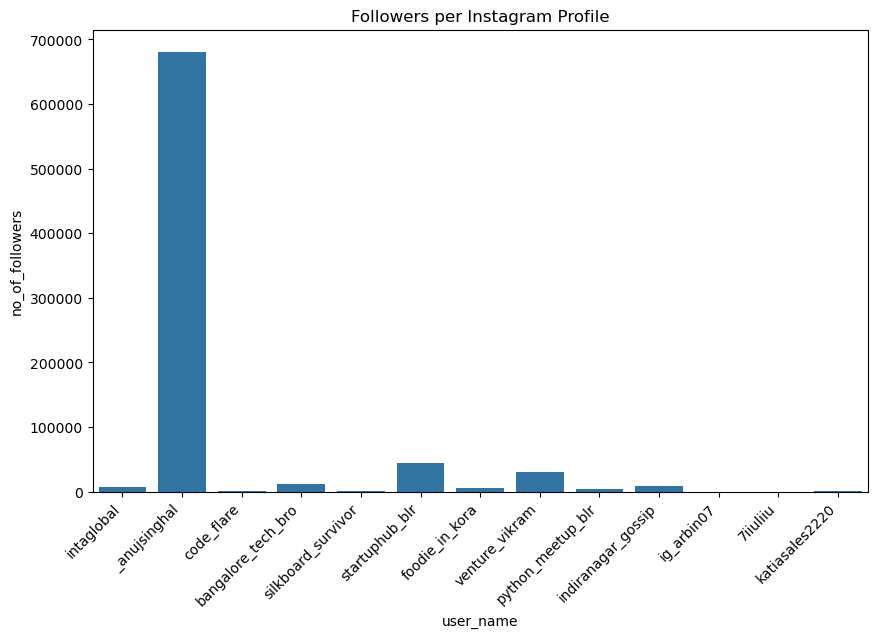

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="user_name", y="no_of_followers", data=df)
plt.xticks(rotation=45, ha="right")
plt.title("Followers per Instagram Profile")
plt.show()


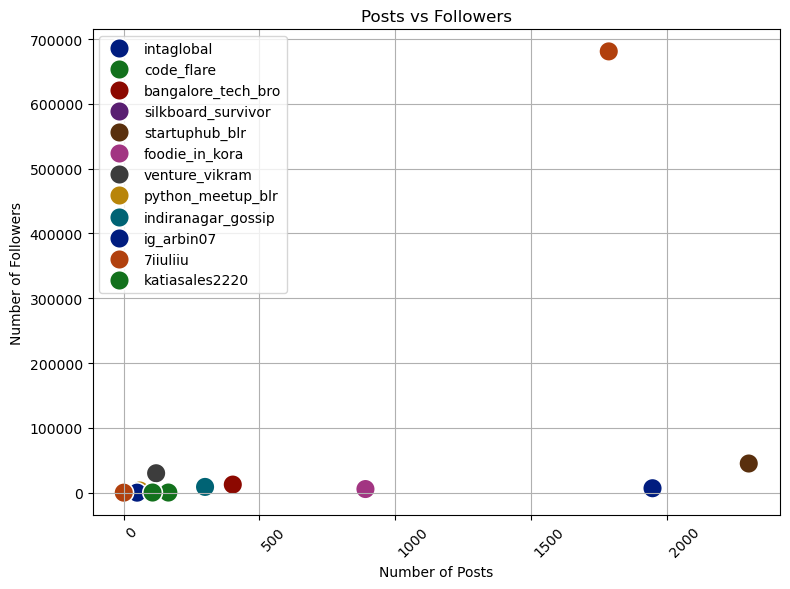

In [42]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="no_of_posts",y="no_of_followers",hue="user_name",palette="dark",data=df, s=200)
plt.title("Posts vs Followers")
plt.xlabel("Number of Posts")
plt.ylabel("Number of Followers")
plt.xticks(rotation=45,ha="left")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Top 5 Profiles by Followers

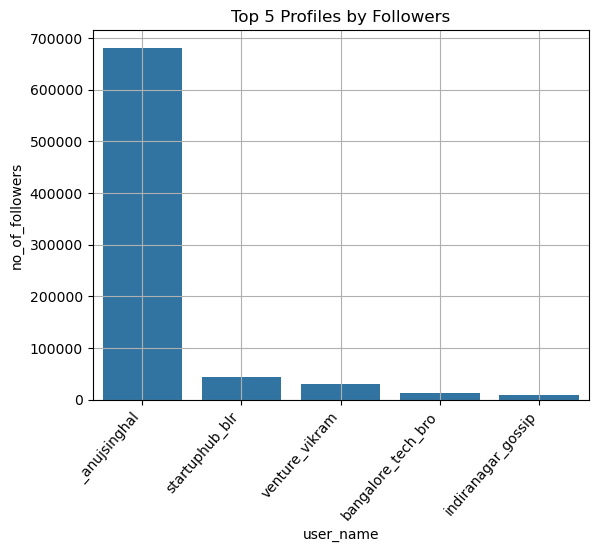

In [43]:
top=df.sort_values("no_of_followers",ascending=False).head(5)
sns.barplot(x="user_name",y="no_of_followers",data=top)
plt.xticks(rotation=49,ha="right")
plt.title("Top 5 Profiles by Followers")
plt.grid("black")
plt.show()

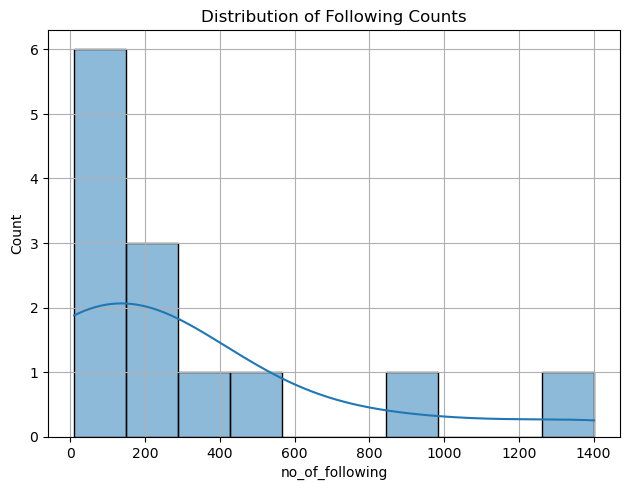

In [44]:
sns.histplot(df["no_of_following"], bins=10, kde=True)
plt.grid(True)
plt.tight_layout()
plt.title("Distribution of Following Counts")
plt.show()


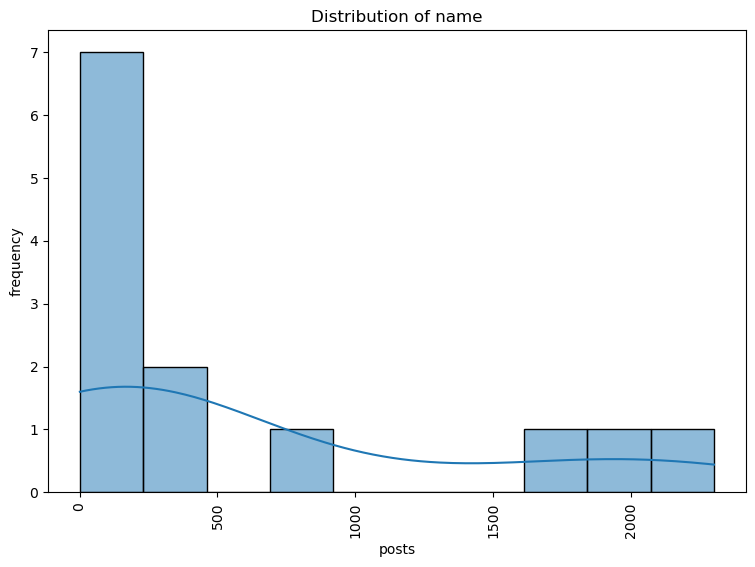

In [45]:
plt.figure(figsize=(9,6))
sns.histplot(df['no_of_posts'],bins=10,kde=True)
plt.title("Distribution of name")
plt.xlabel('posts')
plt.xticks(rotation=90,ha="center")
plt.ylabel('frequency')
plt.show()

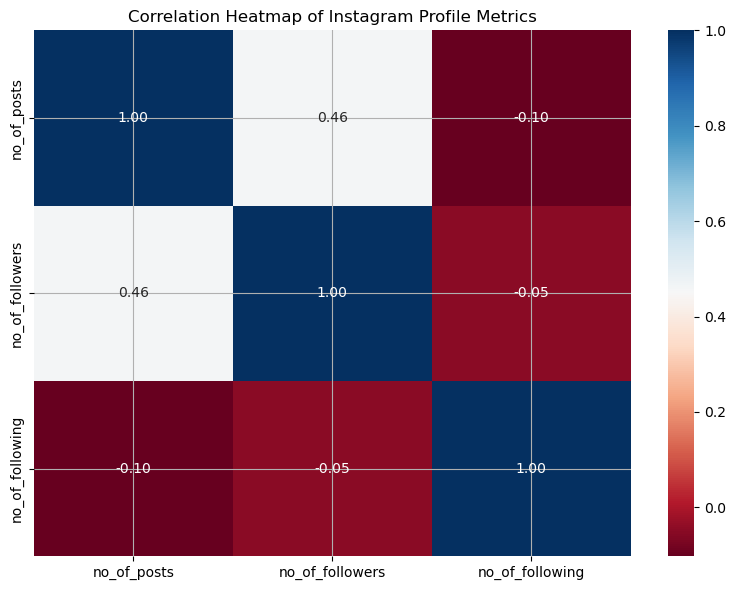

In [49]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="RdBu", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Instagram Profile Metrics")
plt.tight_layout()
plt.grid(True)
plt.show()